# 09 · Measured data

Records from laboratory rigs and observations. The law is known only for the
single pendulum; for the other records the discovered equation is a result to be
interpreted and checked against held-out data.

Displayed outputs are saved examples from earlier executions and do not verify the current version. Re-execute the relevant cells to obtain current results. Searches may reuse a compatible saved run; the printed status identifies this. Recovered laws are established by the reported term comparison, rather than by the presence of a plotted equation.

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
from epde_bench.nbcache import cached_run, print_run
import epde_bench.nbcache as notebook_cache
if os.environ.get('EPDE_BENCH_NOTEBOOK_CACHE'):
    notebook_cache.CACHE_DIR = Path(os.environ['EPDE_BENCH_NOTEBOOK_CACHE'])
from epde_bench.env import seed_everything
seed_everything(0)
from epde_bench.identity import _source_hash
print('Computation source SHA256:', _source_hash())
print('Search cache:', notebook_cache.CACHE_DIR)
from epde_bench.reconstruction import plot_reconstruction
%matplotlib inline
print('EPDE imported; notebook environment ready')

Computation source SHA256: e9af6c769476a35197f9f9a7b0d4ad401ca7b0edeec5bda9c53b9f636b810aa0
Search cache: <repo>/projects/pic/results/notebook_execution_2026-10-09/search_cache
EPDE imported; notebook environment ready


## Single pendulum, encoder measurements

Small swing about the hanging position with the angle centred:

$$\theta'' = -64.8\,\theta - 0.65\,\theta',$$

where $64.8 = g/l$. The undamped form also counts, because the damping is weak.

pend_single: Real single pendulum (encoder, HardwareX rig)
  class: ODE (one equation), source: real
  axes: t; data shape: (5000,); variables: theta
  t: [0, 20], 5000 points
  truth:
    -64.8 * theta{power: 1.0} + -0.65 * dtheta/dx0{power: 1.0} = d^2theta/dx0^2{power: 1.0}
  + 1 equivalent form(s)
  notes: Small swing about the hanging position, angle centred (theta - pi): a damped linear oscillator, -64.8 = -g/l. The undamped form also counts (damping is weak).


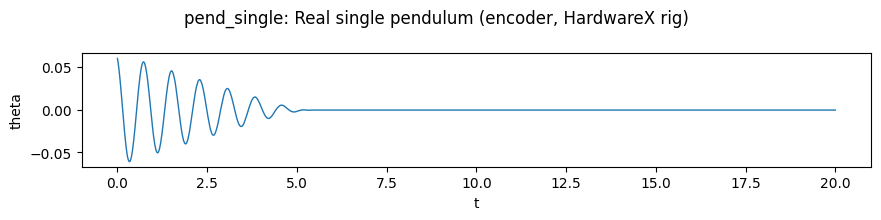

In [2]:
p = datasets.load('pend_single')
print(p.summary())
plot_problem(p); plt.show()

In [3]:
p, report = check('pend_single', noise_levels=[0, 1, 5])
print_check(p, report)

pend_single: Real single pendulum (encoder, HardwareX rig)
  class: ODE (one equation), source: real
  axes: t; data shape: (5000,); variables: theta
  t: [0, 20], 5000 points
  truth:
    -64.8 * theta{power: 1.0} + -0.65 * dtheta/dx0{power: 1.0} = d^2theta/dx0^2{power: 1.0}
  + 1 equivalent form(s)
  notes: Small swing about the hanging position, angle centred (theta - pi): a damped linear oscillator, -64.8 = -g/l. The undamped form also counts (damping is weak).

=== noise 0 % ===
R^2 of the true structure: 0.997326   (d^2theta/dx0^2{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  theta{'power': 1.0}                                             -64.8      -65.059            9.956e-01
  dtheta/dx0{'power': 1.0}                                        -0.65      -0.6456            5.883e-03

=== noise 1 % ===
R^2 of the true structure: 0.994949   (d^2theta/dx0^2{power: 1.0})
  term                                  

In [4]:
rec = cached_run('pend_single', variant='default', noise=0.0, seed=0)
print_run(rec)

Set self._mem_for_cache as 2
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11dcce900>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11dcce900>
Set domain <epde.structure.domain.Domain object at 0x11dccc1a0> with inner shape of [4880]
Deriv orders after definition [[0], [0, 0]]


Added trajectory 0 to exist. traj: dict_keys([])
The cardinality of defined token pool is [1 2 1]
Among them, the pool contains [1 2 1]
No x data in cache for constancy check. Functionality of eval-d token check TBD.
self.vars_demand_equation {'theta'}


The optimization has been conducted.
ok fit 43 s 
[0]
     -0.3971403679658792 * x{power: 1.0, dim: 0.0} * dtheta/dx0{power: 1.0} + -65.00677833294738 * theta{power: 1.0} + 0.0 = d^2theta/dx0^2{power: 1.0}
[1]
     -64.78250995802 * theta{power: 1.0} + 0.0 = d^2theta/dx0^2{power: 1.0}
[2]
     -64.78250995802 * theta{power: 1.0} + 0.0 = d^2theta/dx0^2{power: 1.0}
[3]
     -65.06895142144053 * theta{power: 1.0} + -0.3973565420470344 * dtheta/dx0{power: 1.0} * x{power: 1.0, dim: 0.0} + -0.00221236006890248 * x{power: 1.0, dim: 0.0} + 0.0 = d^2theta/dx0^2{power: 1.0}
[4] <- compromise pick
     -0.08110849085696595 * x{power: 2.0, dim: 0.0} * dtheta/dx0{power: 1.0} + -0.406311982252675 * dtheta/dx0{power: 1.0} + -65.009754837847 * theta{power: 1.0} + 0.0 = d^2theta/dx0^2{power: 1.0}
[5]
     -64.78250995802 * theta{power: 1.0} + 0.0 = d^2theta/dx0^2{power: 1.0}
[6]
     -65.00677833294738 * theta{power: 1.0} + -0.3971403679658792 * dtheta/dx0{power: 1.0} * x{power: 1.0, dim: 0.0} + 0.0 = 

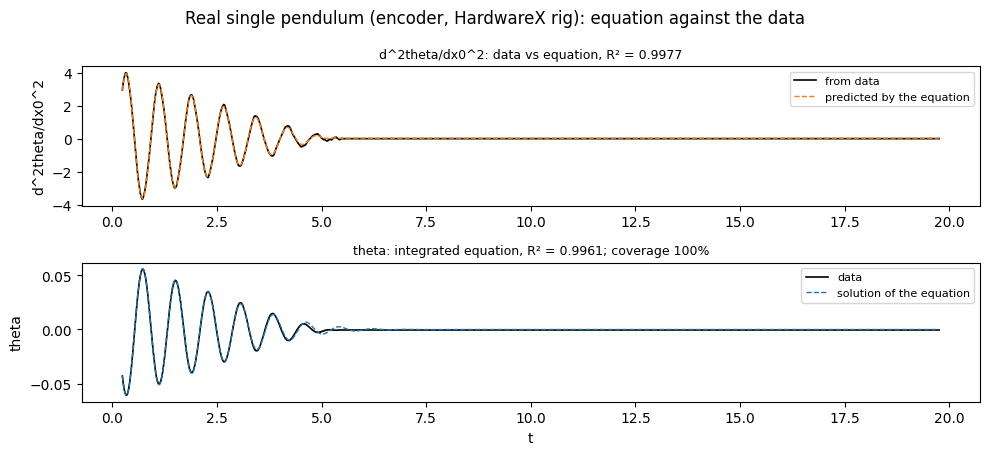

{'d^2theta/dx0^2{power: 1.0}': 0.9977, 'trajectory theta': 0.9961}


In [5]:
problem = datasets.load('pend_single')
search_cfg = resolve_for_problem(load_config('pend_single'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

## Double pendulum

Three records: a simulation, encoder measurements and video tracking. The
equations of motion couple the two angles through sine and cosine of their
difference. The motion is chaotic: a small change of the state or of a
coefficient changes the trajectory after a few swings, and noise in the angles is
amplified in their second derivatives. A discovered equation of a double pendulum
can therefore be compared with the data only on short horizons. The searches are
long and are run from the command line.

## Double pendulum, simulation

Used by the solver studies; the law is not scored.

dp_sim: Simulated double pendulum
  class: system of ODEs, source: synthetic
  axes: t; data shape: (1001,); variables: theta1, theta2
  t: [0, 10], 1001 points
  truth: unknown
  notes: Used by the PINN studies in dp/. The equations of motion need coupling tokens and are not written in token form here.


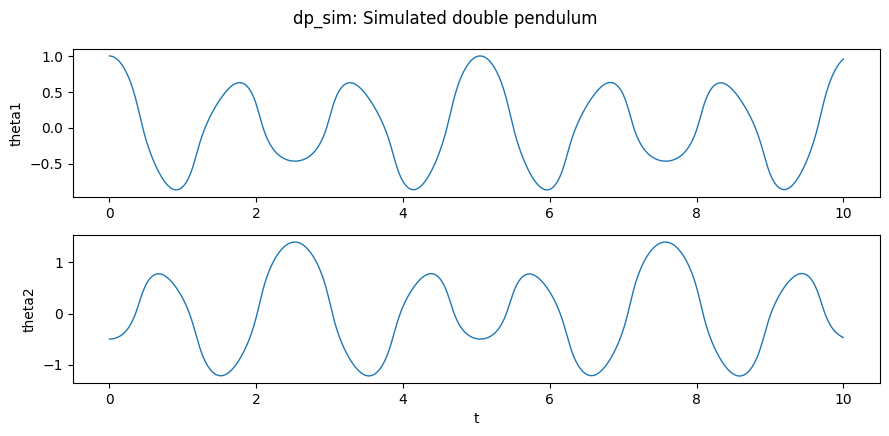

In [6]:
p = datasets.load('dp_sim')
print(p.summary())
plot_problem(p); plt.show()

This section does not run a discovery. The data and checks shown here do not establish that an equation was recovered. A full search can be launched from the command line or the app; no run time or success is claimed here.

## Double pendulum, encoder measurements

Coupled equations of motion with exact coefficients unknown; not scored.

dp_encoder: Real double pendulum (encoder, HardwareX rig)
  class: system of ODEs, source: real
  axes: t; data shape: (6000,); variables: theta1, theta2
  t: [0, 24], 6000 points
  truth: unknown
  notes: Coupled Lagrangian equations with cos/sin of the angle difference; their exact coefficients are not known, so the run is not scored. sin(theta) and the coupling factors enter as tokens.


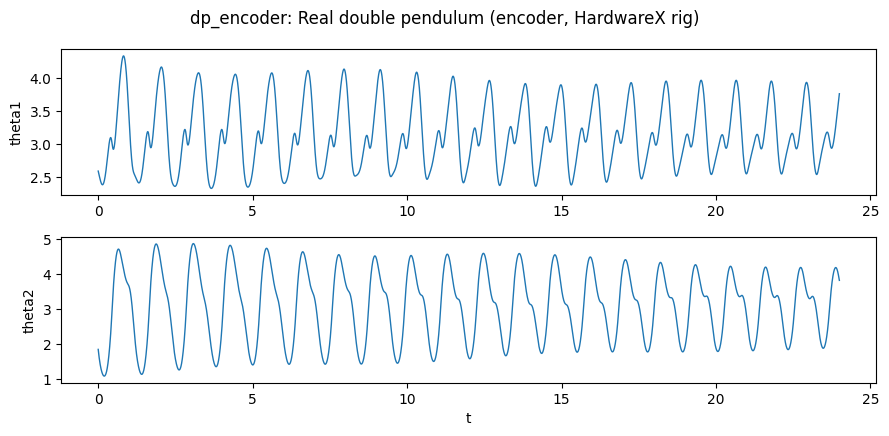

In [7]:
p = datasets.load('dp_encoder')
print(p.summary())
plot_problem(p); plt.show()

This section does not run a discovery. The data and checks shown here do not establish that an equation was recovered. A full search can be launched from the command line or the app; no run time or success is claimed here.

## Double pendulum, video tracking

Mean link angles from video markers; noisier than the encoder record.

dp_video: Real double pendulum (video tracking)
  class: system of ODEs, source: real
  axes: t; data shape: (38827,); variables: theta1, theta2
  t: [0, 77.65], 38827 points
  truth: unknown
  notes: Mean link angles from video markers. Noisier than the encoder record, which is the preferred source.


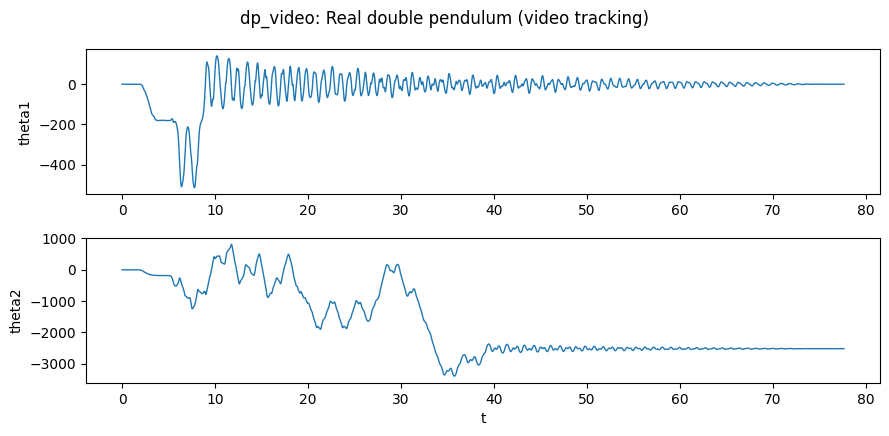

In [8]:
p = datasets.load('dp_video')
print(p.summary())
plot_problem(p); plt.show()

This section does not run a discovery. The data and checks shown here do not establish that an equation was recovered. A full search can be launched from the command line or the app; no run time or success is claimed here.

## Flexible robot arm: input torque and acceleration

A flexible structure of about fifth order driven by a measured torque. The sampling step is not distributed with the file; 0.01 s is assumed, which scales the coefficients but not the structure.

robot_arm: DaISy flexible robot arm (input torque -> acceleration)
  class: ODE (one equation), source: real
  axes: t; data shape: (1024,); variables: y
  t: [0, 10.23], 1024 points
  truth: unknown
  notes: Unknown truth (a ~5th-order flexible structure). dt is not distributed with the file; 0.01 s is assumed (coefficients scale with it, structure does not).


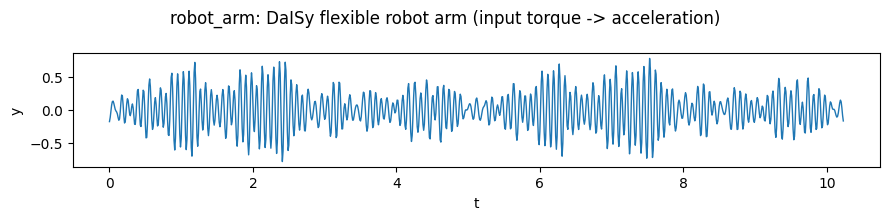

In [9]:
p = datasets.load('robot_arm')
print(p.summary())
plot_problem(p); plt.show()

In [10]:
rec = cached_run('robot_arm', variant='default', noise=0.0, seed=0)
print_run(rec)

Set self._mem_for_cache as 2
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11e200a50>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11e200a50>
Set domain <epde.structure.domain.Domain object at 0x11e04b390> with inner shape of [964]
Deriv orders after definition [[0], [0, 0]]
Added trajectory 0 to exist. traj: dict_keys([])
The cardinality of defined token pool is [1 2 1 1]
Among them, the pool contains [1 2 1 1]
No x data in cache for constancy check. Functionality of eval-d token check TBD.
self.vars_demand_equation {'y'}


The optimization has been conducted.
ok fit 28 s 
[0] <- compromise pick
     -5263.949000589656 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[1]
     -5263.949000589656 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[2]
     -5263.949000589656 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[3]
     -5263.949000589656 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[4]
     -5263.949000589656 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[5]
     -5263.949000589656 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[6]
     -5263.949000589656 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[7]
     -5263.949000589656 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[8]
     -5263.949000589656 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[9]
     -5263.949000589656 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[10]
     -5263.949000589656 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[11]
     -5263.949000589656 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[12]
     -5263.949000589656 

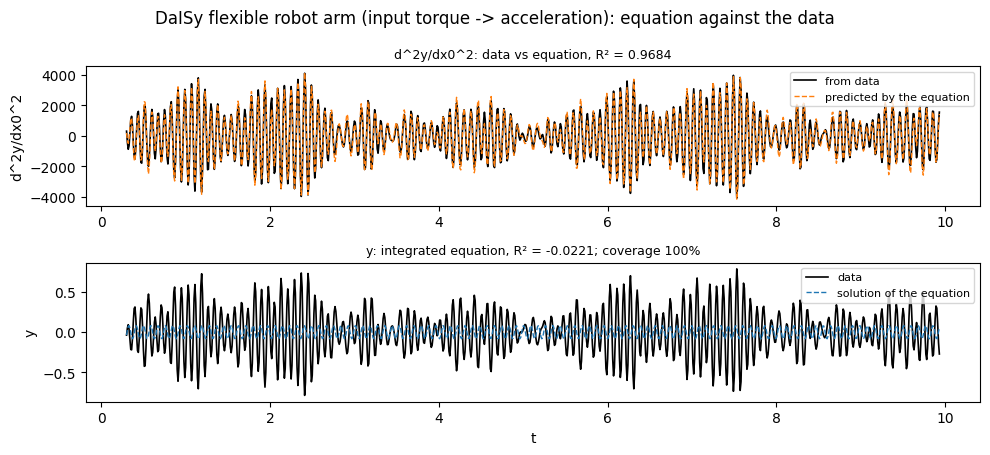

{'d^2y/dx0^2{power: 1.0}': 0.9684, 'trajectory y': -0.0221}


In [11]:
problem = datasets.load('robot_arm')
search_cfg = resolve_for_problem(load_config('robot_arm'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

## Ball on a beam: beam angle and ball position

Idealised physics: the acceleration of the ball is proportional to the beam angle, $y'' = a\,u_{in}$. Sampling period 0.1 s.

ballbeam: DaISy ball and beam (beam angle -> ball position)
  class: ODE (one equation), source: real
  axes: t; data shape: (1000,); variables: y
  t: [0, 99.9], 1000 points
  truth: unknown
  notes: Unknown truth; idealised physics is y'' proportional to the beam angle. Sampling period 0.1 s per the DaISy description.


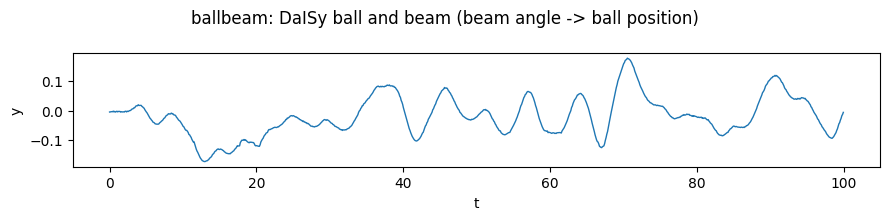

In [12]:
p = datasets.load('ballbeam')
print(p.summary())
plot_problem(p); plt.show()

In [13]:
rec = cached_run('ballbeam', variant='default', noise=0.0, seed=0)
print_run(rec)

Set self._mem_for_cache as 2
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11e04b390>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11e04b390>
Set domain <epde.structure.domain.Domain object at 0x11e0dcf50> with inner shape of [940]
Deriv orders after definition [[0], [0, 0]]
Added trajectory 0 to exist. traj: dict_keys([])
The cardinality of defined token pool is [1 2 1 1]
Among them, the pool contains [1 2 1 1]
No x data in cache for constancy check. Functionality of eval-d token check TBD.
self.vars_demand_equation {'y'}


The optimization has been conducted.
ok fit 34 s 
[0] <- compromise pick
     4.3814718844068015 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[1]
     4.3814718844068015 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[2]
     4.3814718844068 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[3]
     4.3814718844068015 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[4]
     4.3814718844068015 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[5]
     4.3814718844068 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[6]
     4.3814718844068015 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[7]
     4.3814718844068015 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[8]
     4.3814718844068015 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[9]
     -2.7739858269971127 * u_in{power: 1.0} * d^2y/dx0^2{power: 1.0} + 2.464999519809555 * u_in{power: 1.0} * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0} * y{power: 1.0}
{'front_size': 10, 'selected_index': 0}


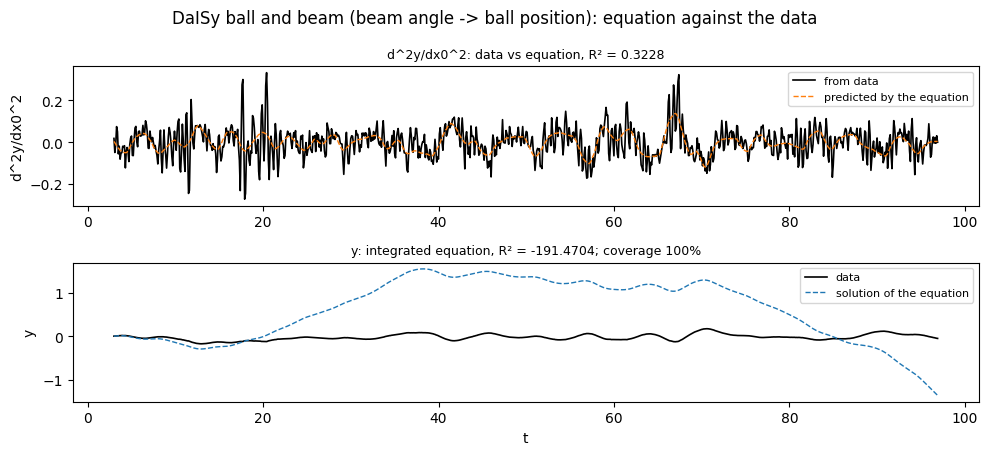

{'d^2y/dx0^2{power: 1.0}': 0.3228, 'trajectory y': -191.4704}


In [14]:
problem = datasets.load('ballbeam')
search_cfg = resolve_for_problem(load_config('ballbeam'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

### Held-out check of the ball-on-beam model

The search above uses the whole record, so its coefficient is not an independent
estimate. The check below fixes the structure $y'' = a\,u_{in}$ in advance, fits
$a$ on the first 70 % of the record and evaluates the last 30 %. Derivatives are
computed separately in each part, with eight points dropped at each end, so test
values do not reach the training part through differentiation.

The acceleration score tests the local relation. The position is then obtained by
integrating the model with the measured test input from the measured initial
position and velocity; its drift reveals bias, missing dynamics and errors in the
initial velocity. A negative score means an error larger than that of a constant
mean.

{'coefficient': 4.421889443526598, 'train_stop': 69.9, 'test_start': 70.0, 'train_samples': 684, 'test_samples': 284, 'acceleration': {'rmse': 0.060592241378360674, 'r2': 0.21466731312497234}, 'trajectory': {'rmse': 0.8149714275901537, 'r2': -169.5498799864859}}


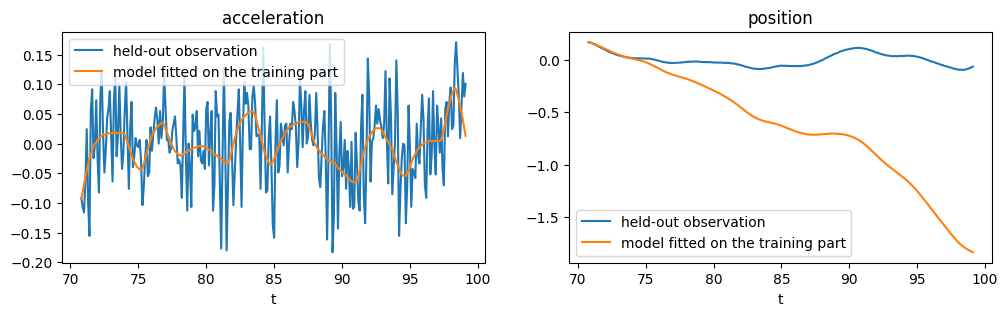

In [15]:
from epde_bench.application import ballbeam_validation
validation = ballbeam_validation()
print({k: validation[k] for k in ['coefficient', 'train_stop', 'test_start',
      'train_samples', 'test_samples', 'acceleration', 'trajectory']})
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, actual, predicted, label in [
    (axes[0], 'observed_acceleration', 'predicted_acceleration', 'acceleration'),
    (axes[1], 'observed_y', 'predicted_y', 'position')]:
    ax.plot(validation['time'], validation[actual], label='held-out observation')
    ax.plot(validation['time'], validation[predicted], label='model fitted on the training part')
    ax.set_title(label); ax.set_xlabel('t'); ax.legend()
plt.show()

The acceleration is explained only partly and the integrated position drifts
away within the test part: proportionality to the beam angle alone does not
describe this record well enough for simulation.

## Sea surface temperature, satellite analysis (January–March 2025)

Daily analysed temperature over 90 days. By default the largest rectangular ocean region that is finite on every day is used; the original box with land masked as missing values can be loaded for plotting only. The governing law is not known.

sst: Sea surface temperature, ESA CCI L4 (Jan-Mar 2025)
  class: PDE, 2 space dimensions, source: real
  axes: t, lat, lon; data shape: (90, 268, 384); variables: T
  t: [0, 89], 90 points
  lat: [25.02, 38.38], 268 points
  lon: [-44.97, -25.83], 384 points
  truth: unknown
  notes: Daily analysed sea surface temperature (K), 90 days. By default the largest rectangular ocean region finite on every day is used; the original box with land masked can be loaded for plotting only.


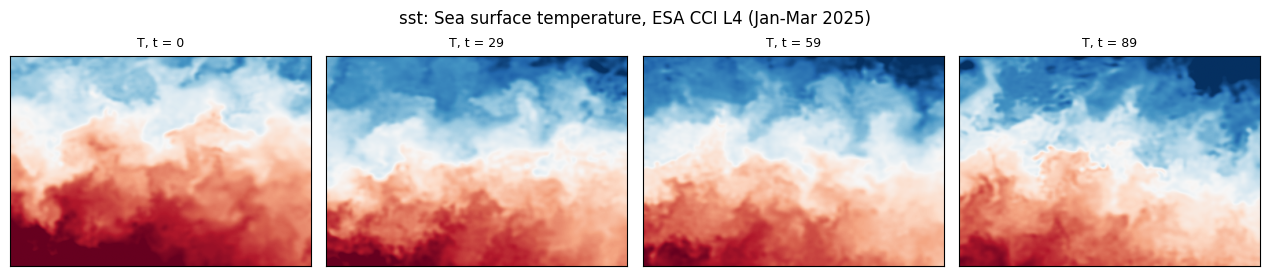

In [16]:
p = datasets.load('sst')
print(p.summary())
plot_problem(p); plt.show()

This section does not run a discovery. The data and checks shown here do not establish that an equation was recovered. A full search can be launched from the command line or the app; no run time or success is claimed here.